In [1]:
import pandas as pd
import sqlite3

df = pd.read_csv(r"C:\Users\Muskan\OneDrive\Documents\Telco-Customer-Churn.csv")

conn = sqlite3.connect("telco.db")
df.to_sql("customers", conn, if_exists="replace", index=False)


7043

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("telco.db")

query = """
SELECT COUNT(*) AS total_customers 
FROM customers;
"""

pd.read_sql(query, conn)



,total_customers
0,7043


In [7]:
pd.read_sql("""
SELECT 
  (COUNT(CASE WHEN Churn='Yes' THEN 1 END) * 100.0) / COUNT(*) 
  AS churn_rate
FROM customers;
""", conn)


,churn_rate
0,26.536987


In [8]:
pd.read_sql("""
SELECT 
  Contract,
  COUNT(*) AS total_customers,
  SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned
FROM customers
GROUP BY Contract;
""", conn)


,Contract,total_customers,churned
0,Month-to-month,3875,1655
1,One year,1473,166
2,Two year,1695,48


In [9]:
pd.read_sql("""
SELECT 
  Churn,
  AVG(MonthlyCharges) AS avg_monthly_charges
FROM customers
GROUP BY Churn;
""", conn)


,Churn,avg_monthly_charges
0,No,61.265124
1,Yes,74.441332


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [13]:
df = pd.read_csv(r"C:\Users\Muskan\OneDrive\Documents\Telco-Customer-Churn.csv")


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)


In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [16]:
cols = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'InternetService',
    'Contract', 'PaperlessBilling'
]

le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])


In [17]:
X = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges',
     'Contract', 'InternetService', 'PaperlessBilling']
]

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.7889125799573561

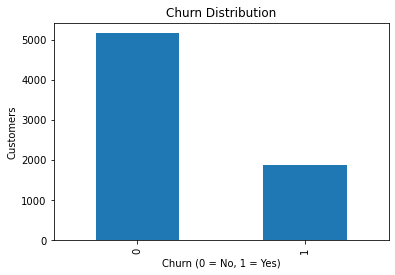

In [19]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customers")
plt.show()


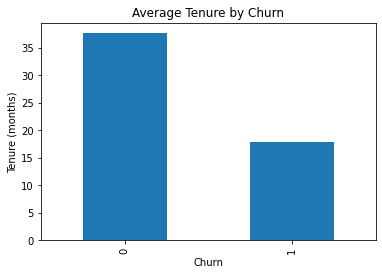

In [20]:
df.groupby('Churn')['tenure'].mean().plot(kind='bar')
plt.title("Average Tenure by Churn")
plt.ylabel("Tenure (months)")
plt.show()


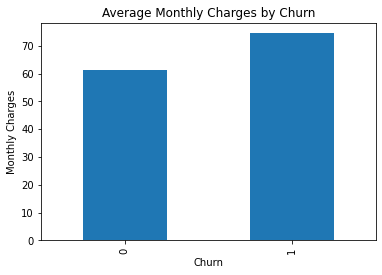

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar')
plt.title("Average Monthly Charges by Churn")
plt.ylabel("Monthly Charges")
plt.show()


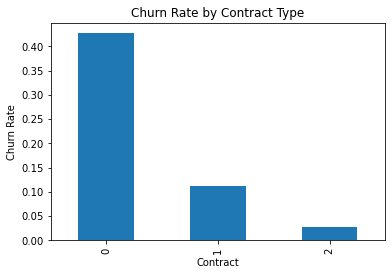

In [22]:
df.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()


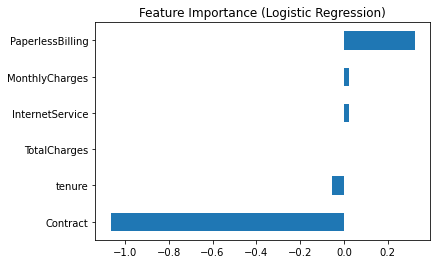

In [23]:
importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values()

importance.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression)")
plt.show()


In [24]:
kpi = pd.DataFrame({
    'total_customers': [df.shape[0]],
    'churned_customers': [df[df['Churn'] == 1].shape[0]],
    'churn_rate_percent': [
        (df[df['Churn'] == 1].shape[0] / df.shape[0]) * 100
    ]
})

kpi.to_csv("kpi_summary1.csv", index=False)


In [25]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True)\
    .rename('percentage').reset_index()

contract_churn.to_csv("contract_churn.csv", index=False)


In [26]:
tenure_churn = df.groupby('tenure')['Churn'].value_counts(normalize=True)\
    .rename('percentage').reset_index()

tenure_churn.to_csv("tenure_churn.csv", index=False)


In [27]:
charges_churn = df.groupby('Churn').agg(
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean')
).reset_index()

charges_churn.to_csv("charges_churn.csv", index=False)


In [28]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True)\
    .rename('percentage').reset_index()

internet_churn.to_csv("internet_churn.csv", index=False)
